# Chip Visualization Notebook

Please run each cell one by one. Many of them are just helper functions that produce the plot at the end. 

### Import Libraries

In [69]:
from pathlib import Path
from io import BytesIO
import json
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, ListedColormap
from PIL import Image as PILImage
from IPython.display import display, Image as DisplayImage, Markdown
import re # for string cleaning
import netCDF4 as nc
import glob
import os
import random

from matplotlib.collections import LineCollection

### Configuation

Change values as needed. You can change the path to the most recent chips, number of chips, the ABI band that you want to visualize, how fast the gif plays, and if you would like random chips, or the first n chips.

In [83]:
 
# ============================================================
# Configuration
# ============================================================
 
CHIP_DIR='/explore/nobackup/projects/pix4dcloud/aliewehr/chipTests/sampleChips/7steps_no_merra2_2400margin_180stride'



N_CHIPS = 1
ABI_BAND = 13 # this seems to be good for seeing the ground and the clouds. also, the range is 0-15
FPS = 1.0
 
# "random" or "first"
SELECTION = "random"

# Options: "CloudSat/cloud_class", "CloudSat/pressure",
# "CloudSat/temperature", "CloudSat/specific_humidity"                         
CLOUDSAT_2D_VAR = "CloudSat/temperature"                                   
                                                                               
# Options: "red" (solid), "CloudSat/temperature_2m", 
# "CloudSat/skin_temperature", "CloudSat/surface_pressure", 
# "CloudSat/u10_velocity", "CloudSat/v10_velocity"                             
TRANSECT_VAR = "CloudSat/skin_temperature" 
 

These are the Cloudsat transect cloud colors, that match to the different cloud types. 

-1 = missing value; 0 = clear; 1 = cirrus; 2= altostratus; 3=altocumulus; 4=stratus; 5=stratocumulus; 6=cumulus; 7=nimbostratus; 8=deep convection

In [84]:
cloud_colors = [
    "#777777",  # -1: missing retrieval
    "#ffffff",  #  0: valid clear
    "#66c2ff",  #  1
    "#33a02c",  #  2
    "#e31a1c",  #  3
    "#9467bd",  #  4
    "#8c564b",  #  5
    "#e377c2",  #  6
    "#bcbd22",  #  7
    "#17becf",  #  8
]
 
cloud_cmap = ListedColormap(cloud_colors)
cloud_norm = BoundaryNorm(
    np.arange(-1.5, 9.5, 1),
    cloud_cmap.N,
)

### File Helpers

In [85]:
def open_npz_file(npz_path):
    try:
        archive = np.load(npz_path, allow_pickle=True)
        return archive
    except Exception as e:
        print(f"Error opening {npz_path}: {str(e)}")
        return None

# Function to find all npz files in a directory
def find_npz_files(directory_path):
    """Find all .npz files in a directory"""
    npz_pattern = os.path.join(directory_path, "*.npz")
    npz_files = glob.glob(npz_pattern)
    npz_files.sort()  
    return npz_files

### Visualization helpers

In [86]:
def track_distance_km(latitude, longitude):
    latitude = np.deg2rad(latitude)
    longitude = np.deg2rad(longitude)
 
    if len(latitude) < 2:
        return np.zeros(len(latitude))
 
    delta_latitude = np.diff(latitude)
    delta_longitude = np.diff(longitude)
 
    haversine = (
        np.sin(delta_latitude / 2) ** 2
        + np.cos(latitude[:-1])
        * np.cos(latitude[1:])
        * np.sin(delta_longitude / 2) ** 2
    )
 
    segments = (
        2
        * 6371.0
        * np.arcsin(np.sqrt(haversine))
    )
 
    return np.concatenate([
        [0.0],
        np.cumsum(segments),
    ])
 
 
def band_limits(chip, band_index):
    values = chip[..., band_index]
    valid = values[np.isfinite(values)]
 
    if valid.size == 0:
        return 0.0, 1.0
 
    lower, upper = np.percentile(valid, [2, 98])
 
    if np.isclose(lower, upper):
        upper = lower + 1.0
 
    return float(lower), float(upper)

The two cells below contain large arrays that contain the latitude and longitude that match up with the coordinates in each of the chip file names. This is how we get the lat and lon for each chip.  

In [10]:
EAST_LATLONDATA = "/explore/nobackup/projects/pix4dcloud/jgong/ABI_EAST_GEO_TOPO_LOMSK.nc"
EAST_f_coords = nc.Dataset(EAST_LATLONDATA)
EAST_abiLong = np.array(EAST_f_coords['Longitude'])
EAST_abiLat = np.array(EAST_f_coords['Latitude'])
EAST_abiLong[EAST_abiLong == -999] = 10
EAST_abiLat[EAST_abiLat == -999] = 10
# abiLong[abiLong < 0] += 360
print(EAST_abiLat.shape)

(10848, 10848)


In [11]:
WEST_LATLONDATA = "/explore/nobackup/projects/pix4dcloud/jgong/ABI_WEST_GEO_TOPO_LOMSK.nc"
WEST_f_coords = nc.Dataset(WEST_LATLONDATA)
WEST_abiLong = np.array(WEST_f_coords['Longitude'])
WEST_abiLat = np.array(WEST_f_coords['Latitude'])
WEST_abiLong[WEST_abiLong == -999] = 10
WEST_abiLat[WEST_abiLat == -999] = 10
# abiLong[abiLong < 0] += 360
print(WEST_abiLat.shape)


(10848, 10848)


### Functions that actually draw the gif 

In [87]:
def draw_abi(lon_chip, lat_chip, cloudsat_latitude, cloudsat_longitude, axis, sample, frame, band_index, limits, transect_var=TRANSECT_VAR):
    band = sample["ABI/chip"][frame, :, :, band_index]
 
    lower, upper = limits
    normalized = np.clip(
        (band - lower) / (upper - lower),
        0,
        1,
    )
 
    axis.pcolormesh(lon_chip, lat_chip, band, cmap='gray', shading='gouraud')


    if transect_var == 'red':
        axis.plot(cloudsat_longitude, cloudsat_latitude, color='red', linewidth=2, label='CloudSat Track')
    else:
        values = sample[transect_var]
        sc = axis.scatter(cloudsat_longitude, cloudsat_latitude, c=values, cmap='coolwarm', s=12, zorder=3)
        cbar = axis.figure.colorbar(sc, ax=axis, orientation='horizontal', pad=0.15)
        cbar.set_label(transect_var.split('/')[-1])
        

 
    offset = int(
        sample["ABI/offsets_minutes"][frame]
    )
    scan_time = str(
        sample["ABI/scan_times"][frame]
    )
    valid = int(
        sample["ABI/valid_mask"][frame]
    )
 
    axis.set_title(
        f"ABI C{ABI_BAND:02d} | "
        f"{offset:+d} min | valid={valid}\n"
        f"{scan_time}"
    )
 
    axis.set_xlabel("ABI column")
    axis.set_ylabel("ABI row")
 
 
def draw_cloudsat_mask(axis, sample, variable_name=CLOUDSAT_2D_VAR):
 
    mask = sample[variable_name]
 
    distance = track_distance_km(
        sample["CloudSat/latitude"],
        sample["CloudSat/longitude"],
    )
 
    maximum_distance = max(
        float(distance[-1]),
        1e-6,
    )


    if variable_name == 'CloudSat/cloud_class':
        im = axis.imshow(
            mask.T,
            origin="lower",
            aspect="auto",
            interpolation="nearest",
            extent=[
                0,
                maximum_distance,
                0,
                mask.shape[1] * 0.5,
            ],
            cmap=cloud_cmap,
            norm=cloud_norm,
        )
    else:
        # Map different variables to suitable continuous colormaps         
            cmap_dict = {                                                      
                "CloudSat/pressure": "viridis",                                
                "CloudSat/temperature": "coolwarm",                            
                "CloudSat/specific_humidity": "Blues",                         
            }                                                                  
            selected_cmap = cmap_dict.get(variable_name, "viridis") # default is viridis         
                                                                               
            im = axis.imshow(                                                  
                mask.T,                                                        
                origin="lower",                                                
                aspect="auto",                                                 
                interpolation="bilinear",  # bilinear looks smoother for continuous variables                                                         
                extent=[0, maximum_distance, 0, mask.shape[1] * 0.5],          
                cmap=selected_cmap,                                            
            )                                                                  
                                                                               
            # Add a horizontal colorbar under the subplot                      
            cbar = axis.figure.colorbar(im, ax=axis, orientation="horizontal", pad=0.15)                                                                    
            cbar.set_label(variable_name.split("/")[-1])    
    



    
    axis.set_xlabel("Distance along track (km)")
    axis.set_ylabel("Altitude (km)")
    axis.set_ylim(0, 20)
 
 
half = 256
 
def make_gif(path):
    sample = open_npz_file(path)

    band_index = ABI_BAND - 1
    limits = band_limits(
        sample["ABI/chip"],
        band_index,
    )

    chip = sample['ABI/chip']

    cloudsat_latitude = sample['CloudSat/latitude']
    cloudsat_longitude = sample['CloudSat/longitude']

    fileName = path.split('/')[-1]
    # r c p is row column is profile index

    fileNameSplit = fileName.split('_')

    row =re.sub(r'[^0-9]', '', fileNameSplit[-4]) 
    col = re.sub(r'[^0-9]', '', fileNameSplit[-3])
    length = re.sub(r'[^0-9]', '', fileNameSplit[-1])
    eastOrWest = fileNameSplit[1]


    y_center = int(row)
    x_center = int(col)

    lat_chip = 'placeholder'
    lon_chip = 'placeholder'

    if eastOrWest == 'east':
        lat_chip = EAST_abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
        lon_chip = EAST_abiLong[y_center-half : y_center+half, x_center-half : x_center+half]
    else:
        lat_chip = WEST_abiLat[y_center-half : y_center+half, x_center-half : x_center+half]
        lon_chip = WEST_abiLong[y_center-half : y_center+half, x_center-half : x_center+half]
 
    frames = []
 
    for frame in range(
        sample["ABI/chip"].shape[0]
    ):
        figure, axes = plt.subplots(
            1,
            2,
            figsize=(18, 8),
            dpi=90,
        )
 
        draw_abi(
            lon_chip, lat_chip,
            cloudsat_latitude, 
            cloudsat_longitude,
            axes[0],
            sample,
            frame,
            band_index,
            limits,
            transect_var=TRANSECT_VAR
        )
 
        draw_cloudsat_mask(
            axes[1],
            sample,
            variable_name=CLOUDSAT_2D_VAR
        )
 
        figure.suptitle(
            fileName,
            fontsize=10,
        )
 
        figure.tight_layout(
            rect=(0, 0, 1, 0.95)
        )
 
        figure.canvas.draw()
 
        image = PILImage.fromarray(
            np.asarray(
                figure.canvas.buffer_rgba()
            )
        ).convert("RGB")
 
        frames.append(image)
        plt.close(figure)
 
    buffer = BytesIO()
 
    frames[0].save(
        buffer,
        format="GIF",
        save_all=True,
        append_images=frames[1:],
        duration=int(1000 / FPS),
        loop=0,
        disposal=2,
        optimize=False,
    )

    # # Replacement Code:
    # buffer = BytesIO()
        
    # # 1. Convert the first frame to palette mode ("P") using an adaptive palette
    # first_frame_p = frames[0].convert("P", palette=Palette.ADAPTIVE, colors=256)
        
    # # 2. Force all subsequent frames to use the exact same palette
    # other_frames_p = [f.quantize(palette=first_frame_p) for f in frames[1:]]
        
    # # 3. Save the GIF using the stabilized frames
    # first_frame_p.save(
    #     buffer,
    #     format="GIF",
    #     save_all=True,
    #     append_images=other_frames_p,
    #     duration=int(1000 / FPS),
    #     loop=0,
    #     disposal=2,
    # )
 
    return buffer.getvalue()


Based on your selection at the start, the output will be different. The cell below applies your input. 

In [88]:

chip_files = find_npz_files(CHIP_DIR)
 
if not chip_files:
    raise FileNotFoundError(
        f"No NPZ files found in {CHIP_DIR}"
    )
 
elif SELECTION == "random":
    rng = np.random.default_rng()
 
    count = min(
        N_CHIPS,
        len(chip_files),
    )
 
    indices = rng.choice(
        len(chip_files),
        size=count,
        replace=False,
    )
 
    selected_files = [
        chip_files[index]
        for index in indices
    ]
 
elif SELECTION == "first":
    selected_files = chip_files[:N_CHIPS]
 
else:
    raise ValueError(
        "SELECTION must be "
        "'random', or 'first'"
    )
 

# Create and display GIFs directly in the notebook

Displaying 1 of 161 chips


### Chip 1/1


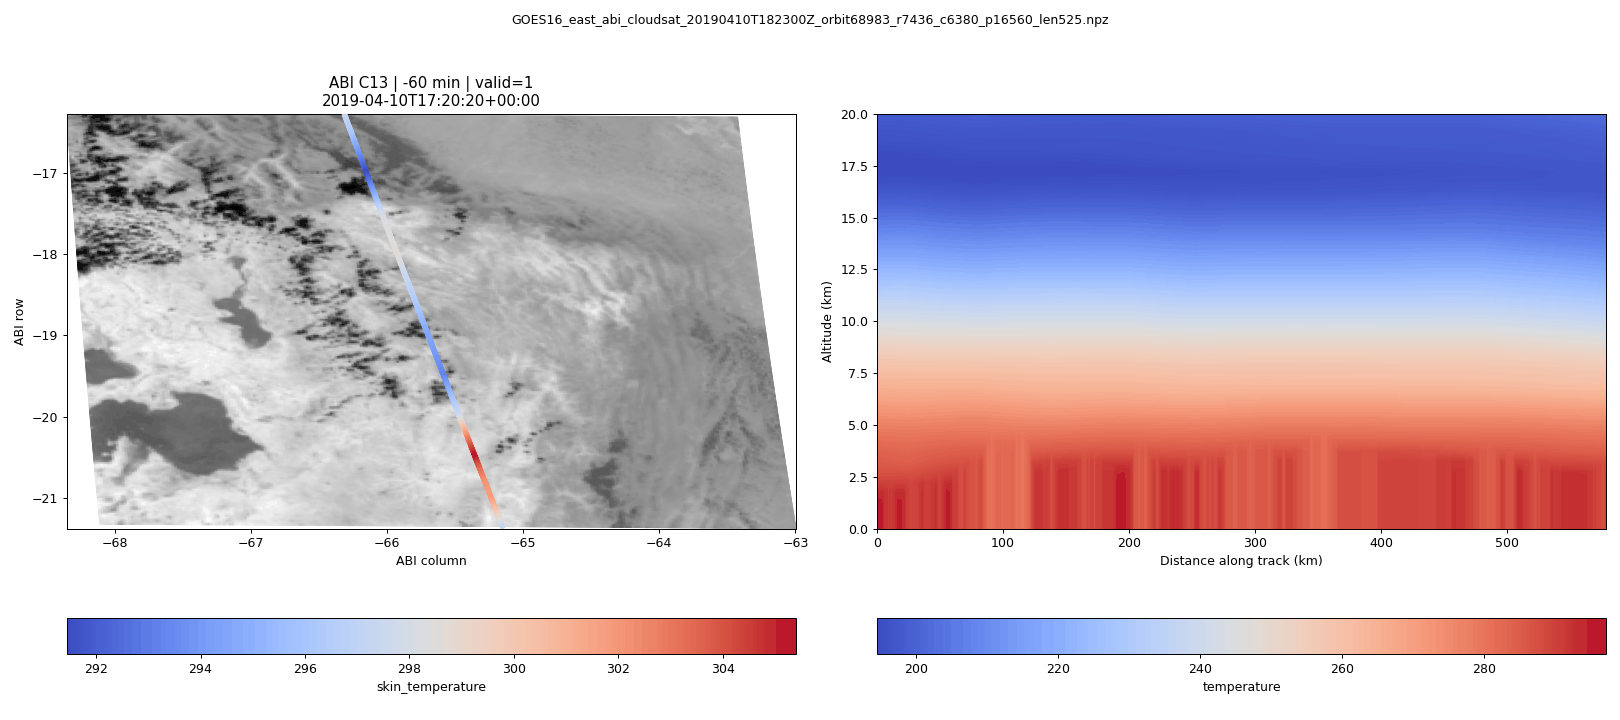

In [89]:
print(
    f"Displaying {len(selected_files)} "
    f"of {len(chip_files)} chips"
)
 
for chip_number, path in enumerate(
    selected_files,
    start=1,
):
 
    display(
        Markdown(
            f"### Chip {chip_number}/"
            f"{len(selected_files)}\n"
        )
    )
 
    gif_data = make_gif(path)

    # with open(f'chip{chip_number}.gif', 'wb') as f:
    #     f.write(gif_data)
 
    display(
        DisplayImage(
            data=gif_data,
            format="gif",
        )
    )